# Method development: Random Forest Regression
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

In [2]:
# Importing clean dataset
df_listings = pd.read_parquet('../data/clean_listings.parquet', engine='auto')

In [3]:
non_null_count_listings = df_listings.notnull().sum().values
nulls = df_listings.isna().sum()
types = df_listings.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                         Non-Null Count  Null Count   Dtypes
listing_id                        68683          16    Int64
listing_type                      68699           0      str
room_type                         68699           0      str
cover_photo_url                   68699           0      str
photos_count                      68699           0    Int64
host_id                           68699           0      str
superhost                         68699           0  boolean
guests                            68699           0    Int64
bedrooms                          68699           0    Int64
beds                              68699           0  float64
baths                             68699           0  float64
registration                      68474         225  boolean
amenities                         68699           0      str
amenities_count                   68699           0    int64
instant_book                      14283       54416  boolean
professional_management 

In [4]:
df_listings.columns

Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'guests', 'bedrooms', 'beds',
       'baths', 'registration', 'amenities', 'amenities_count', 'instant_book',
       'professional_management', 'min_nights', 'cancellation_policy',
       'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall',
       'rating_accuracy', 'rating_checkin', 'rating_cleanliness',
       'rating_communication', 'rating_location', 'rating_value',
       'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy',
       'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_adjusted_revpar',
       'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days',
       'country', 'city'],
      dtype='str')

In [20]:
# Selecting cols
cols = [
    'room_type', 'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths', 
    'amenities_count', 'cleaning_fee', 'num_reviews', 'rating_overall', 'ttm_revenue',
    'country', 'city', 'registration', 'instant_book', 'professional_management', 'min_nights',
    'cancellation_policy', 'extra_guest_fee',
]

df_listings_cols = df_listings[cols].copy()

In [21]:
# Splitting columns
categorical_cols = df_listings_cols.select_dtypes(include=["object"]).columns.to_list()
numerical_cols = [col for col in df_listings_cols if col not in categorical_cols]

print(df_listings_cols.isna().sum())
print(len(df_listings_cols))
# Not the best approach, but simple solution for testing
df_listings_cols = df_listings_cols.dropna()
print(len(df_listings_cols))

room_type                      0
photos_count                   0
superhost                      0
guests                         0
bedrooms                       0
beds                           0
baths                          0
amenities_count                0
cleaning_fee                1262
num_reviews                    0
rating_overall                 0
ttm_revenue                    0
country                        0
city                           0
registration                 225
instant_book               54416
professional_management     7642
min_nights                     0
cancellation_policy            9
extra_guest_fee             2209
dtype: int64
68699
7798


In [22]:
# Extracting features
feature_cols = [c for c in cols if c != 'ttm_revenue']
X = df_listings_cols[feature_cols]
print(X)

# Extracting target variable
y = df_listings_cols['ttm_revenue'].values
print(y)

         room_type  photos_count  superhost  guests  bedrooms  beds  baths  \
13     entire_home            46      False       6         4   5.0    3.0   
20     entire_home            83      False       8         4   4.0    4.0   
21     entire_home            23      False       2         1   1.0    1.0   
24     entire_home            32      False       6         2   3.0    2.5   
30     entire_home            99      False      11         5   7.0    4.5   
...            ...           ...        ...     ...       ...   ...    ...   
95792  entire_home             8      False       3         2   2.0    1.0   
95859  entire_home            27      False       5         3   4.0    2.0   
95866  entire_home             8      False       2         1   1.0    1.0   
95881  entire_home             9       True       1         1   1.0    1.0   
95890  entire_home            16      False       4         2   2.0    1.0   

       amenities_count  cleaning_fee  num_reviews  rating_overa

In [23]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X)

         room_type  photos_count  superhost  guests  bedrooms  beds  baths  \
13     entire_home            46      False       6         4   5.0    3.0   
20     entire_home            83      False       8         4   4.0    4.0   
21     entire_home            23      False       2         1   1.0    1.0   
24     entire_home            32      False       6         2   3.0    2.5   
30     entire_home            99      False      11         5   7.0    4.5   
...            ...           ...        ...     ...       ...   ...    ...   
95792  entire_home             8      False       3         2   2.0    1.0   
95859  entire_home            27      False       5         3   4.0    2.0   
95866  entire_home             8      False       2         1   1.0    1.0   
95881  entire_home             9       True       1         1   1.0    1.0   
95890  entire_home            16      False       4         2   2.0    1.0   

       amenities_count  cleaning_fee  num_reviews  rating_overa

In [24]:
# Build preprocessor with One Hot Encoder
cat_features = [c for c in feature_cols if c in categorical_cols]
num_features = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', 'passthrough', num_features)
])

In [25]:
# Build pipeline with model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=400, random_state=42, oob_score=True, n_jobs=-1, max_features='sqrt'))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [26]:
# Making predictions and evaluating

# Estimates the model's generalization performance
print("Out-of-Bag Score:", pipeline['model'].oob_score_)

# Predictions are made on the test set
y_pred = pipeline.predict(X_test)

# Evaluates the model's performance using the Mean Squared Error (MSE) metric
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")  # same unit as ttm_revenue (likely $)

# Also useful: compare error relative to the target's scale
print(f"Mean of y_test: {y_test.mean():.2f}")
print(f"RMSE as % of mean: {(rmse / y_test.mean()) * 100:.2f}%")

# Evaluates the model's performance using the R-squared (R2) metric
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.4589463019241369
Mean Squared Error: 95032680.87544344
RMSE: 9748.47
Mean of y_test: 11970.05
RMSE as % of mean: 81.44%
R-squared: 0.4725970251311825


In [27]:
# Feature importances — reconstruct names after OHE expansion
ohe_feature_names = pipeline['preprocessor'] \
    .named_transformers_['ohe'] \
    .get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

importances = pd.Series(
    pipeline['model'].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

print(importances.head(15))

cleaning_fee                0.083400
bedrooms                    0.069716
baths                       0.069217
guests                      0.067829
num_reviews                 0.065536
amenities_count             0.058884
photos_count                0.056118
beds                        0.053863
rating_overall              0.053024
city_City of Westminster    0.043114
min_nights                  0.029043
country_United Kingdom      0.020842
instant_book                0.015639
superhost                   0.015292
cancellation_policy_Firm    0.011390
dtype: float64


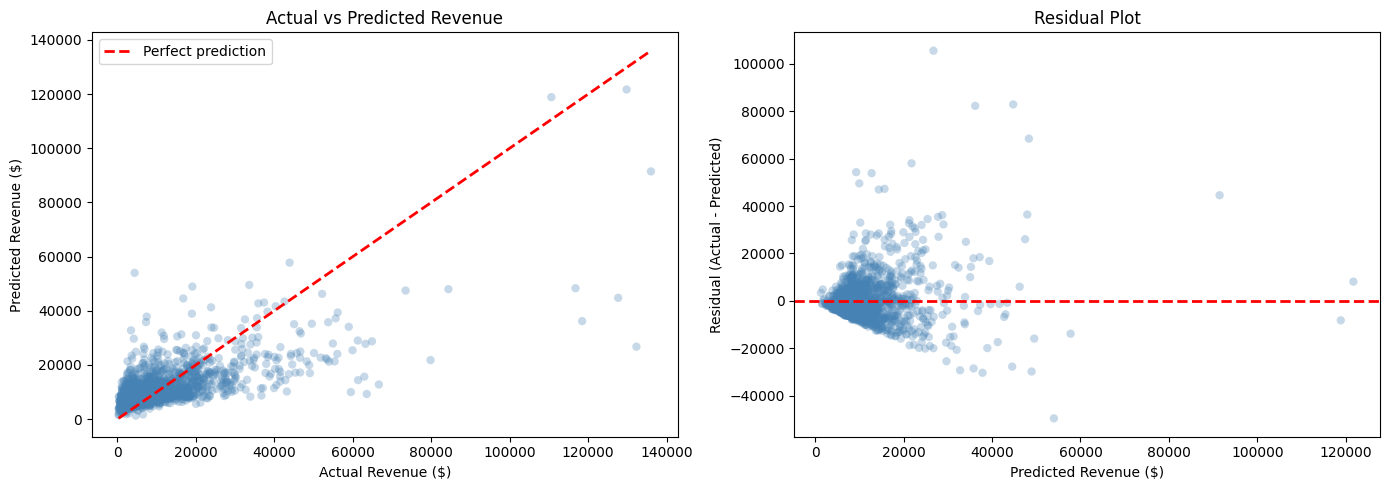

In [28]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].set_title('Actual vs Predicted Revenue')
axes[0].legend()

# --- Plot 2: Residuals ---
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Revenue ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

n=50: OOB=0.4156
n=100: OOB=0.4276
n=150: OOB=0.4362
n=200: OOB=0.4440
n=250: OOB=0.4467
n=300: OOB=0.4461
n=400: OOB=0.4498
n=500: OOB=0.4485


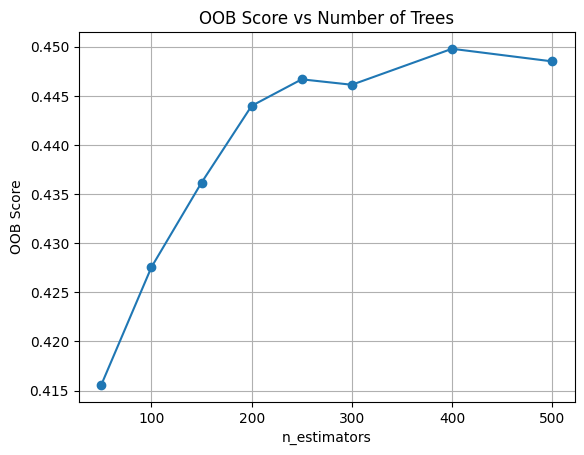

In [19]:
import matplotlib.pyplot as plt

oob_scores = []
estimator_range = [50, 100, 150, 200, 250, 300, 400, 500]
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)

for n in estimator_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )
    rf.fit(X_train_transformed, y_train)  # use the preprocessed array
    oob_scores.append(rf.oob_score_)
    print(f"n={n}: OOB={rf.oob_score_:.4f}")

plt.plot(estimator_range, oob_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('OOB Score')
plt.title('OOB Score vs Number of Trees')
plt.grid(True)
plt.show()